<a href="https://colab.research.google.com/github/ssylviawolf-0/CARNIVALGAME-SOFTWARE/blob/main/analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🧠 AI for Healthcare: Building a Diagnostic Model

Welcome! In this workshop, we will build a real machine learning model used in healthcare.

By the end, you will:
- Understand how data is used in medicine
- Train a model to predict cancer risk
- Interpret what the model learns

---

## 🧬 Dataset

We are using a real-world dataset of breast tumor measurements.

Each row = one patient  
Each column = a measurement of the tumor  

Our goal:
Predict whether a tumor is **malignant (cancerous)** or **benign (non-cancerous)**

In [ ]:
# Core libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# 🔹 Step 1: Load and Explore the Data

Let’s load the dataset and take a look.

In [ ]:
data = load_breast_cancer()

df = pd.DataFrame(data.data, columns=data.feature_names)
df["target"] = data.target

df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


## 🧠 Understanding the Data

- Features = tumor characteristics (size, texture, etc.)
- Target:
  - 0 = malignant (cancer)
  - 1 = benign (no cancer)

In [ ]:
df["target"].value_counts()

,count
target,
1,357
0,212


# 🔹 Step 2: Visualizing the Data

Let’s explore one feature: **mean radius**

Question:
Do cancerous tumors tend to be larger?

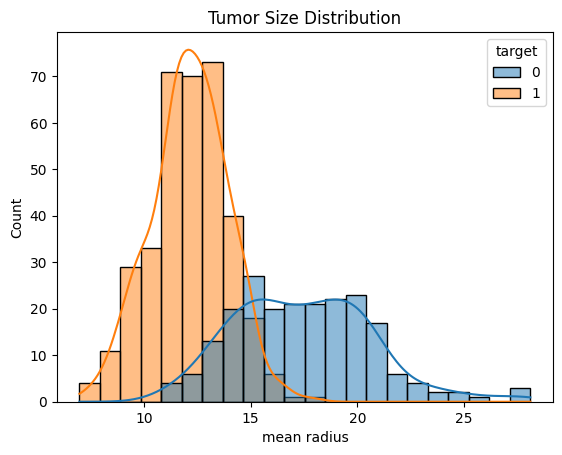

In [ ]:
sns.histplot(data=df, x="mean radius", hue="target", kde=True)
plt.title("Tumor Size Distribution")
plt.show()

👉 What differences do you notice between the two groups?

Core idea of machine learning:

➡️ Finding patterns in data

# 🔹 Step 3: Correlation Heatmap

Let’s see how features relate to each other.

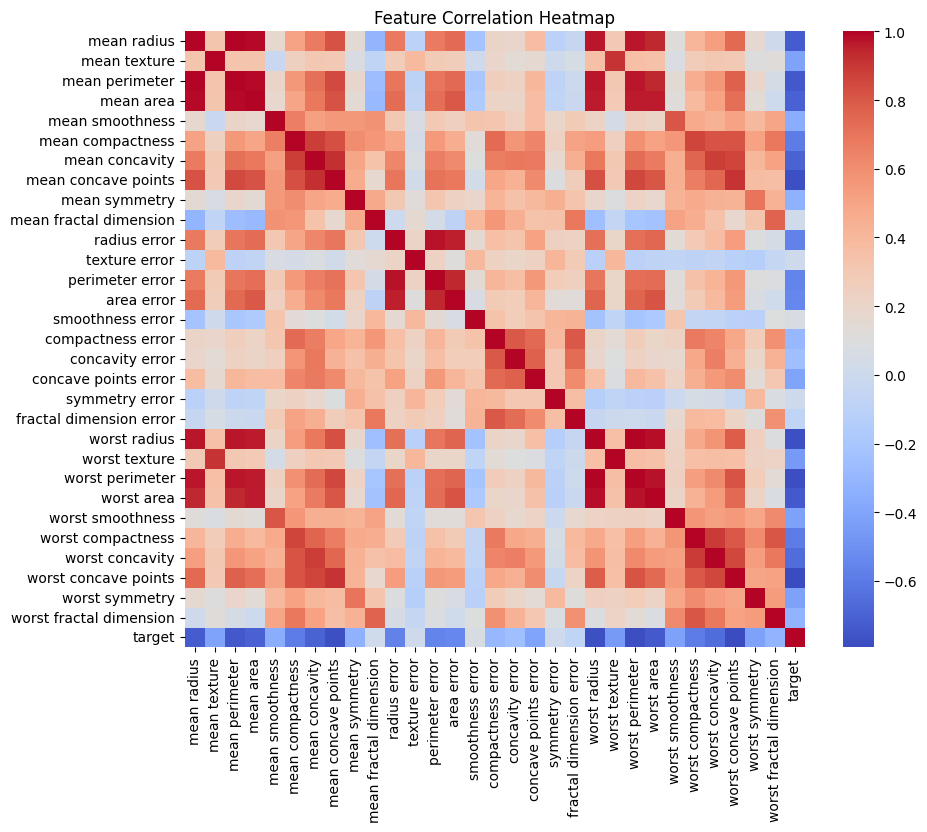

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

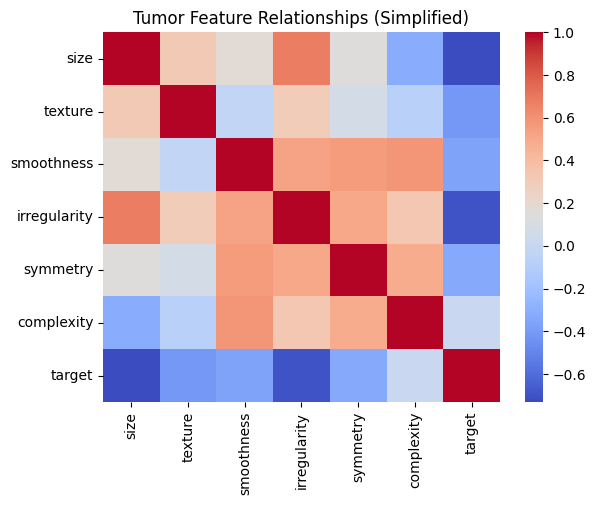

In [ ]:
df_simplified = pd.DataFrame({
    "size": df["mean radius"],
    "texture": df["mean texture"],
    "smoothness": df["mean smoothness"],
    "irregularity": df["mean concavity"],
    "symmetry": df["mean symmetry"],
    "complexity": df["mean fractal dimension"],
    "target": df["target"]
})

sns.heatmap(df_simplified.corr(), cmap="coolwarm")
plt.title("Tumor Feature Relationships (Simplified)")
plt.show()

Negative correlation means higher values of this feature are associated with cancer.

👉 Why might some features be highly correlated?

💡 Real biological systems often have relationships between measurements.

# 🔹 Step 4: Train a Machine Learning Model

Now we build our AI model.

Steps:
1. Split data into training/testing sets
2. Train the model
3. Evaluate performance

In [ ]:
X = df.drop("target", axis=1)
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

accuracy = model.score(X_test, y_test)
print("Model Accuracy:", accuracy)

Model Accuracy: 0.9649122807017544


🎉 We just built a model that predicts cancer risk!

👉 Is this good? What might be limitations?

# 🔹 Step 5: Feature Importance

Which features matter most to the model?

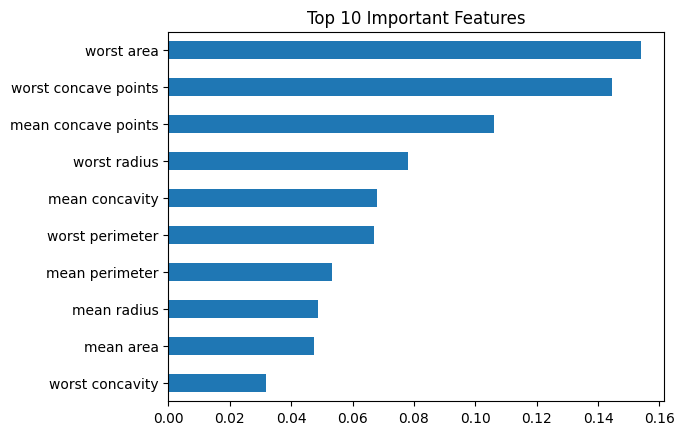

In [ ]:
importance = pd.Series(model.feature_importances_, index=X.columns)

importance.sort_values().tail(10).plot(kind="barh")
plt.title("Top 10 Important Features")
plt.show()

👉 Which measurements seem most important? And does this make sense?

💡 This is how doctors and researchers gain insight from models.

# 🔹 Step 6: Predict a Patient Outcome

Let’s simulate a real clinical decision.

In [ ]:
# Select a sample patient
sample = X_test.iloc[0]

# Get prediction and actual value
prediction = model.predict([sample])[0]
actual = y_test.iloc[0]

# Convert to readable labels
pred_label = "Benign" if prediction == 1 else "Malignant"
actual_label = "Benign" if actual == 1 else "Malignant"

# Display patient features nicely
print("🧬 Patient Features:\n")
display(sample.to_frame(name="Value"))

# Show prediction vs actual
print("\n🔍 Model Prediction:", pred_label)
print("🧠 Actual Diagnosis:", actual_label)

🧬 Patient Features:



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


,Value
mean radius,12.470000
mean texture,18.600000
mean perimeter,81.090000
mean area,481.900000
mean smoothness,0.099650
mean compactness,0.105800
mean concavity,0.080050
mean concave points,0.038210
mean symmetry,0.192500
mean fractal dimension,0.063730



🔍 Model Prediction: Benign
🧠 Actual Diagnosis: Benign


In [ ]:
# Select 20 random patients from the test set
sample_batch = X_test.sample(20, random_state=42)
actual_batch = y_test.loc[sample_batch.index]

# Make predictions
predictions = model.predict(sample_batch)

# Convert to readable labels
pred_labels = ["Benign" if p == 1 else "Malignant" for p in predictions]
actual_labels = ["Benign" if a == 1 else "Malignant" for a in actual_batch]

# Create a results table
results_df = pd.DataFrame({
    "Predicted": pred_labels,
    "Actual": actual_labels
})

# Display results
print("🧪 Predictions for 20 Patients:\n")
display(results_df)

🧪 Predictions for 20 Patients:



,Predicted,Actual
0,Malignant,Malignant
1,Benign,Benign
2,Benign,Benign
3,Benign,Benign
4,Benign,Benign
5,Benign,Benign
6,Malignant,Malignant
7,Malignant,Malignant
8,Benign,Benign
9,Malignant,Malignant


🧠 Final Thought:

You just:
- Loaded real medical data
- Built a machine learning model
- Interpreted its decisions

👉 This is exactly how AI is used in healthcare today.

---

# 🚀 Bonus (Optional)

Try:
- Changing the model
- Testing different features
- Predicting more patients
